In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('Sales (1).csv')
df.head()

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,2013-11-26,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,2015-11-26,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,2014-03-23,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,2016-03-23,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,2014-05-15,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418


In [ ]:
#Initial inspection
print("Shape:", df.shape)
print("\nColumn dtypes:\n", df.dtypes)
print("\nNull values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

In [ ]:
#Descriptive statistics
numerical_cols = df.select_dtypes(include=[np.number]).columns
desc_stats = df[numerical_cols].agg(['mean', 'median', 'std'])
mode_stats = df[numerical_cols].mode().iloc[0]
desc_stats.loc['mode'] = mode_stats
desc_stats

In [ ]:
#Time series analysis
# Convert to datetime and create a proper Year-Month period
df['Date'] = pd.to_datetime(df['Date'])
df['YearMonth'] = df['Date'].dt.to_period('M')
df['Quarter'] = df['Date'].dt.to_period('Q')

# Monthly sales trend
monthly_sales = df.groupby('YearMonth')['Revenue'].sum()
plt.figure(figsize=(14, 6))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Quarterly sales trend
quarterly_sales = df.groupby('Quarter')['Revenue'].sum()
plt.figure(figsize=(14, 6))
quarterly_sales.plot(kind='line', marker='o', color='darkorange')
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

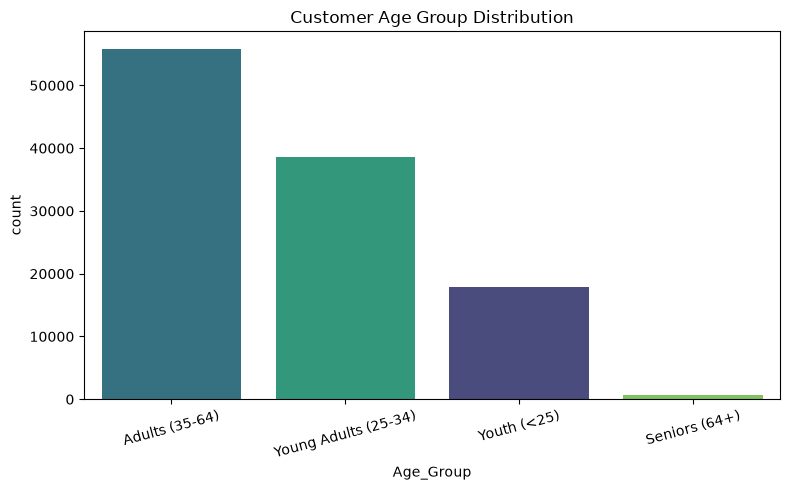

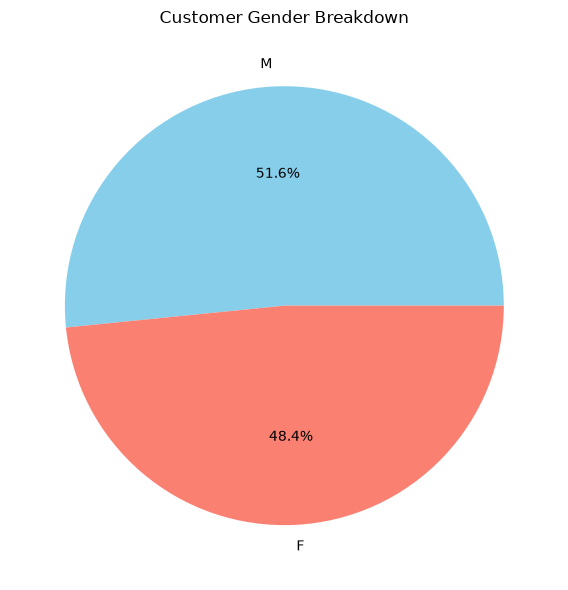

In [10]:
# Age group distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Age_Group', order=df['Age_Group'].value_counts().index, hue='Age_Group', palette='viridis')
plt.title('Customer Age Group Distribution')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Gender breakdown
plt.figure(figsize=(6, 6))
df['Customer_Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'salmon'])
plt.title('Customer Gender Breakdown')
plt.ylabel('')
plt.tight_layout()
plt.show()

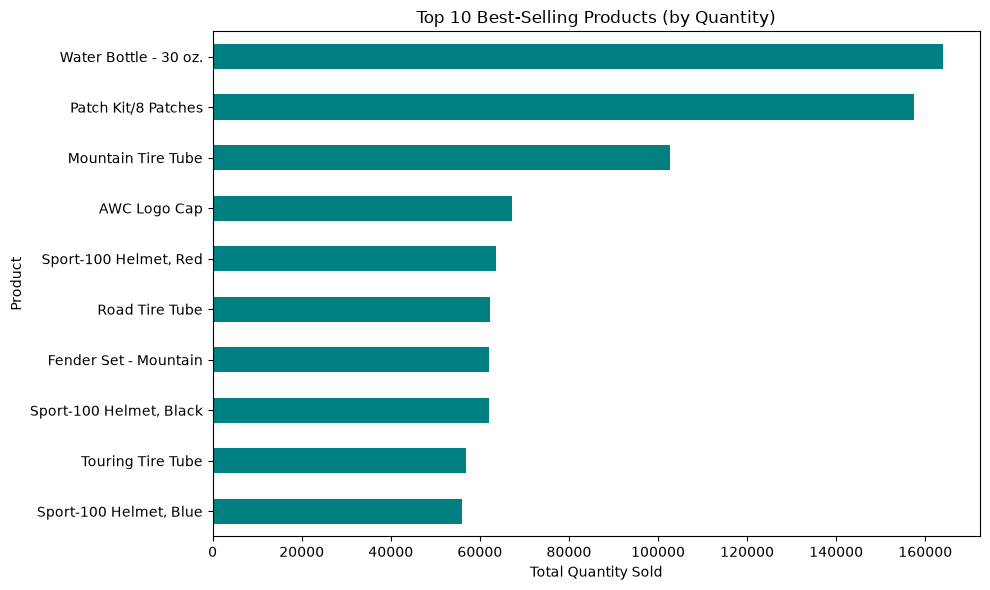

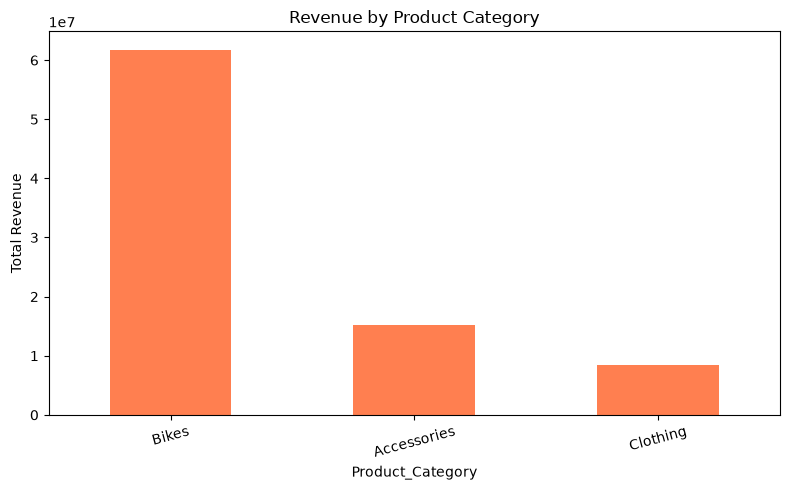

In [7]:
# Top 10 best-selling products (by quantity)
top_products = df.groupby('Product')['Order_Quantity'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
top_products.plot(kind='barh', color='teal')
plt.title('Top 10 Best-Selling Products (by Quantity)')
plt.xlabel('Total Quantity Sold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Revenue by product category
category_revenue = df.groupby('Product_Category')['Revenue'].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
category_revenue.plot(kind='bar', color='coral')
plt.title('Revenue by Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

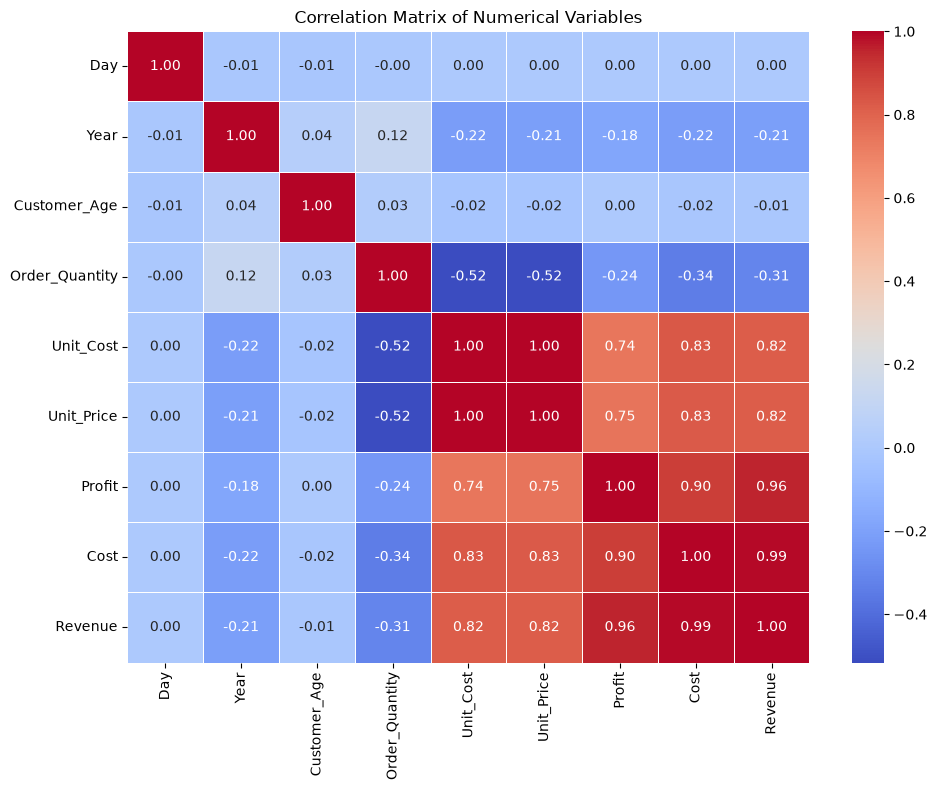

In [8]:
plt.figure(figsize=(10, 8))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

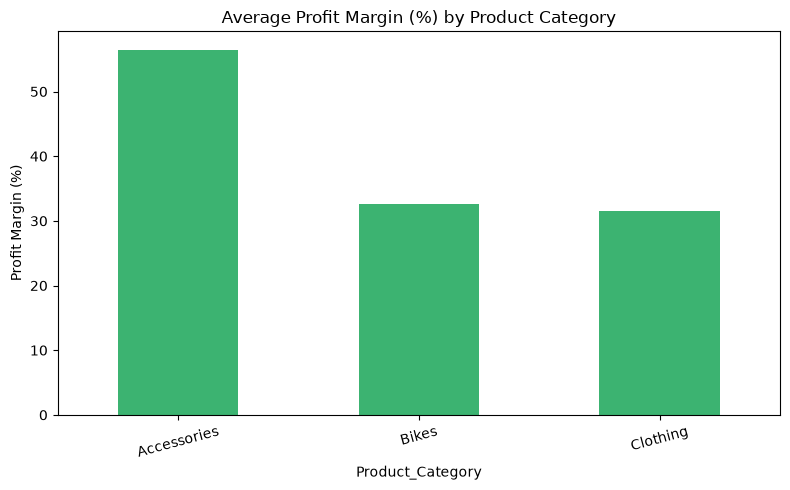

In [9]:
# Profit margin (%) by product category
df['Profit_Margin'] = (df['Profit'] / df['Revenue']) * 100
margin_by_cat = df.groupby('Product_Category')['Profit_Margin'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
margin_by_cat.plot(kind='bar', color='mediumseagreen')
plt.title('Average Profit Margin (%) by Product Category')
plt.ylabel('Profit Margin (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()